# Fate preferences, saturating interactions, and predicted-curvature propagation

**Role:** Training/fitting.

Fit interpretable fate-only predictors of Gaussian curvature (target 0), mean curvature (target 1), or both. Exclusive identities include Unassigned. Whole-neighborhood source abundance within two hops activates each ordered pair once; the distribution of those source cells between exact rings sets the distance contribution. Linear, fixed normalized tanh, and learned normalized tanh responses are compared on identical saved outer folds. Propagation averages **predicted**, never measured, neighbor curvature.

Constant and smooth-in-log-N models share the same separately fitted global baselines. Thus “constant” refers to the local fate/propagation parameters, not the baseline. Joint models share saturation parameters only; center preferences, distance amplitudes and coupling remain target-specific. Losses give equal weight to organoids and to targets scaled by training residual RMS. These are statistical curvature-field models, not fitted membrane energies or causal cell interactions.

The Gaussian experiment contains 16 configurations per fold (center plus three activation families, each with/without propagation and N dependence). Mean-only and joint experiments add the four learned-saturation configurations each. The reference supplies exact outer memberships, Gaussian preprocessing/baselines and exclusive fates. Mean targets come from the original source graph on those same nodes; new cleanup thresholds and a new mean baseline use outer-training organoids only. All models, per-target baselines, transformations, memberships, inner selections and convergence diagnostics are stored in a new timestamped run. Existing results are preserved. Evaluation is in `experiments/benchmarks/coupled_fate_evaluation.ipynb`.

In [1]:
from pathlib import Path
import sys
from IPython import get_ipython
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').is_file())  # Repository root.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import copy
import gc
import time
from html import escape
from concurrent.futures import ThreadPoolExecutor, wait, FIRST_COMPLETED
import ipywidgets as widgets
import hashlib
import itertools
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from src.artifacts.runs import AnalysisRun
from src.artifacts.bundle import save_bundle, load_bundle, graph_membership
from src.artifacts.paths import training_run_path
from src.artifacts.provenance import workflow_fingerprint
from src.training.preparation import physical_fate_fold, prepare_fold, combine_target_folds
from src.training.coupled_fit import graph_samples, fit_fate_response, response_mse
from src.training.progress import TrainingProgress
from src.data.preprocessing import interpolate_target_outliers_from_neighbors
from src.models.coupled_fate import normalized_tanh, neighbor_average_matrix
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib', 'inline')
torch.set_num_threads(4)

## Configuration
Choose the model grid and numerical settings here, before data loading or plotting helpers. The source supplies all cohort filters and exact memberships. Fixed alpha is chosen before inspecting validation results.

In [2]:
# Execution and source cohort
RUN_TRAINING = True  # Permit fitting; False only inspects settings/cohort.
SHOW_PROGRESS = True  # Display active model, target, fold and solver stage.
REFERENCE_RUN = 'training_results/fate_masking_training/Ndependent_20260922_115100'  # Exact source folds and Gaussian reference.
RESUME_RUN = 'training_results/coupled_fate_training/activation_curvatures_20260928_170831'  # Existing incomplete run path to resume completed checkpoint bundles.

CONCURRENT_FITS = 2  # Independent fits in parallel; bound CPU and memory use.

SETTINGS = dict(
    # Experiment design
    tag='activation_curvatures',  # Purpose label before the timestamp.
    target_sets={'gaussian':[0], 'mean':[1], 'joint':[0,1]},  # Raw graph target columns.
    gaussian_families=['center','linear','fixed','learned'],  # Full activation comparison on Gaussian curvature.
    additional_families=['learned'],  # Mean and joint target comparisons.
    size_modes=[False,True],  # Constant versus smooth N-dependent local parameters.
    propagation_modes=[False,True],  # Local model versus shared predicted-curvature propagation.
    pair_radius=2,  # Whole-neighborhood abundance and distance shares within these rings.
    n_splines=5,  # Cubic log-N basis size; constant models use one coefficient.
    gamma_max=.95,  # Strict propagation bound below one.
    fixed_alpha=3.,  # Prespecified normalized-tanh saturation for fixed/unsupported pairs.
    min_pair_organoids=20,  # Minimum training organoids with an ordered pair to learn its alpha.

    # Training-only model selection and penalties
    inner_fraction=.2,  # Inner organoid holdout for selecting coefficient penalties.
    seed=42,  # Shared inner split and numerical reproducibility seed.
    ridge=1e-4,  # Center coefficient shrinkage in training-scaled target units.
    pair_ridge_grid=[1e-4,1e-3],  # Inner validation selects pair shrinkage.
    smoothness=.01,  # Second differences of size-dependent fate coefficients.
    gamma_smoothness=.1,  # Second differences of coupling logits over log N.
    gamma_ridge=1e-4,  # Weak penalty on coupling magnitude.
    alpha_ridge=1e-5,  # Weak log-alpha shrinkage toward the fixed response.

    # Profiled nonlinear optimization
    starts=[(.15,1.),(.55,8.)],  # (Coupling, saturation) initializations; chosen by training objective.
    max_iterations=250,  # Maximum optimizer iterations per start.
    tolerance=2e-5,  # Projected-gradient stopping target for normalized loss.
    blas_threads=4,  # CPU linear-algebra threads.
)

## Saved folds and planned comparisons
Audit memberships and display the prespecified response shape. No outer validation score selects activation settings.

,fold,train,validation
0,0,936,234
1,1,936,234
2,2,936,234
3,3,936,234
4,4,936,234


24 models per fold; 120 total fits
Output: training_results/coupled_fate_training/activation_curvatures_20260928_170831


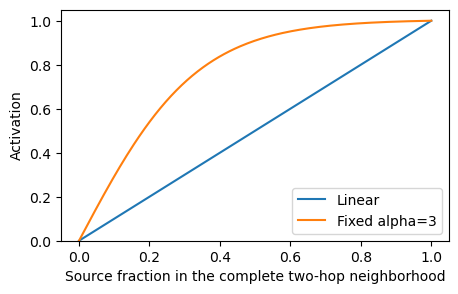

In [3]:
reference = AnalysisRun(PROJECT_ROOT/REFERENCE_RUN)
membership = json.loads((reference.directory/'splits.json').read_text())
cohort_data = load_bundle(reference.directory/'cohort')
marker_names = list(cohort_data['all_marker_names'])
identity_names = marker_names+['Unassigned']
if not reference.settings.get('exclusive_markers'):
    raise ValueError('The source must use exclusive fates.')
input_paths = {}
for split in membership:
    rows = reference.records[(reference.records.fold==split['fold']) & (reference.records.subset=='all') & (reference.records.signal=='intact')]
    paths = rows.input_bundle.dropna().unique()
    if len(paths)!=1:raise ValueError('Ambiguous reference preprocessing.')
    input_paths[split['fold']] = paths[0]
configs = []
for target,indices in SETTINGS['target_sets'].items():
    families = SETTINGS['gaussian_families'] if target=='gaussian' else SETTINGS['additional_families']
    for family,dependent,coupling in itertools.product(families,SETTINGS['size_modes'],SETTINGS['propagation_modes']):
        name = f'{target}_{family}_{"N" if dependent else "constant"}_{"coupled" if coupling else "local"}'
        configs.append(dict(name=name,target_set=target,target_indices=indices,family=family,size_dependent=dependent,coupling=coupling))
SETTINGS.update(reference_run=str(reference.directory),dataset=reference.settings['dataset'],exclusive_markers=True,
    residualize=True,target_scaling='identity',global_features=[],reference_inputs=input_paths)
RUN_DIR = Path(RESUME_RUN) if RESUME_RUN else training_run_path(PROJECT_ROOT,'coupled_fate_training',SETTINGS['tag'])
display(pd.DataFrame([dict(fold=s['fold'],train=len(s['train']),validation=len(s['validation'])) for s in membership]))
print(len(configs),'models per fold;',len(configs)*len(membership),'total fits')
print('Output:',RUN_DIR)
x = np.linspace(0,1,200)
fig,ax = plt.subplots(figsize=(5,3))
ax.plot(x,x,label='Linear');ax.plot(x,normalized_tanh(x,SETTINGS['fixed_alpha']),label=f"Fixed alpha={SETTINGS['fixed_alpha']:g}")
ax.set(xlabel='Source fraction in the complete two-hop neighborhood',ylabel='Activation',ylim=(0,1.05));ax.legend();plt.show()

## Prepare physical residual targets and save baselines
Reuse Gaussian preprocessing unchanged for the FiLM comparison. Fit mean cleanup thresholds and its scalar baseline on the outer-training fold, then apply them to validation. Baselines are frozen across every local-model comparison; inner model selection conditions on these outer-training preprocessing fits. Joint targets reuse the very same scalar baselines. Source node order and edges must match exactly.

In [4]:
if RUN_TRAINING:
    if RUN_DIR.exists():
        if json.loads((RUN_DIR/'settings.json').read_text())!=json.loads(json.dumps(SETTINGS)):
            raise ValueError('Resume settings differ from saved settings.')
    else:
        RUN_DIR.mkdir(parents=True)
        (RUN_DIR/'settings.json').write_text(json.dumps(SETTINGS,indent=2))
        (RUN_DIR/'splits.json').write_text(json.dumps(membership,indent=2))
        (RUN_DIR/'reference_settings.json').write_text(json.dumps(reference.settings,indent=2))
        save_bundle(RUN_DIR/'cohort',cohort_data,splits=membership)
    provenance = dict(code_sha256=workflow_fingerprint(PROJECT_ROOT/'experiments/training/coupled_fate_training.ipynb'))
    if (RUN_DIR/'provenance.json').exists():
        (RUN_DIR/'provenance_before_resume.json').write_text((RUN_DIR/'provenance.json').read_text())
    (RUN_DIR/'provenance.json').write_text(json.dumps(provenance,indent=2))
    for split in membership:
        fold = split['fold']
        if all((RUN_DIR/f'inputs/fold_{fold}_{name}/manifest.json').exists() for name in SETTINGS['target_sets']):continue
        source = load_bundle(reference.directory/input_paths[fold])
        if graph_membership(train=source['groups']['train'],validation=source['groups']['val'])!={k:split[k] for k in ('train','validation')}:
            raise ValueError('Saved split mismatch.')
        gaussian = physical_fate_fold(source)
        mean_graphs = []
        for role in ('train','val'):
            for graph in gaussian['groups'][role]:
                oid = str(graph.organoid_str)
                raw = cohort_data['raw_graphs'][oid]
                path = PROJECT_ROOT/'training_data'/SETTINGS['dataset']/f'{oid}.npz'
                with np.load(path,allow_pickle=False) as data:
                    if len(data['y'])!=len(graph.x) or (neighbor_average_matrix(len(graph.x),data['edges'].T)!=neighbor_average_matrix(len(graph.x),graph.edge_index)).nnz!=0:
                        raise ValueError(f'Source node/edge alignment differs: {oid}')
                    values = data['y'][:,1].copy()
                g = copy.deepcopy(raw);g.x=graph.x.clone();g.edge_index=graph.edge_index.clone();g.y=torch.tensor(values,dtype=torch.float64)
                mean_graphs.append(g)
        nt = len(gaussian['groups']['train'])
        train_mean,cleanup = interpolate_target_outliers_from_neighbors(mean_graphs[:nt],clip_quantiles=reference.settings['outlier_quantiles'],report=False)
        val_mean,val_cleanup = interpolate_target_outliers_from_neighbors(mean_graphs[nt:],clip_quantiles=reference.settings['outlier_quantiles'],fitted_statistics=cleanup,report=False)
        torch.manual_seed(SETTINGS['seed']+fold)
        mean = prepare_fold(train_mean+val_mean,dict(train_indices=list(range(nt)),val_indices=list(range(nt,len(mean_graphs)))),
            global_features=[],residualize=True,target_scaling='identity',baseline_features=reference.settings['baseline_features'],
            baseline_kwargs=dict(hidden_dim=reference.settings['baseline_hidden_dim'],max_epochs=reference.settings['baseline_max_epochs'],
                patience=reference.settings['baseline_patience'],num_workers=0,batch_size=reference.settings['batch_size'],
                train_kwargs=dict(device='cuda' if torch.cuda.is_available() else 'cpu')))
        mean.update(marker_names=marker_names,cleanup_train=cleanup,cleanup_validation=val_cleanup)
        for name,indices in SETTINGS['target_sets'].items():
            path = RUN_DIR/f'inputs/fold_{fold}_{name}'
            if path.exists():continue
            prepared = combine_target_folds({0:gaussian,1:mean},indices)
            prepared.update(marker_names=marker_names)
            save_bundle(path,prepared,splits=split,provenance=provenance)
        print(f'Prepared fold {fold}: Gaussian baseline reused; mean baseline fitted on training organoids.',flush=True)
        del source,gaussian,mean,mean_graphs,prepared
        gc.collect()

## Fit the planned grid
For each propagation/saturation parameter vector, solve all linear coefficients by penalized least squares. Analytic gradients include activation-reference changes and the implicit spatial solve. Multiple starts are ranked by training objective; penalties by the shared inner holdout. Failed convergence is rejected. Saturation is constant across N and shared across outputs; unsupported ordered pairs retain fixed alpha and are marked in the checkpoint. Training-weighted coefficient contrasts and response centering define a reference-dependent decomposition, not intrinsic biological curvature.

The nonlinear solver uses preconditioned BFGS with smooth bounds on saturation. Two initial paths continue through the penalty grid; the selected penalty's inner solutions warm-start outer refits. This changes numerical conditioning and initialization, not the objective. Independent jobs are scheduled by expected cost; one writer publishes completed artifacts.

In [5]:
if RUN_TRAINING:
    catalog_path = RUN_DIR/'models.json'
    records = json.loads(catalog_path.read_text()) if catalog_path.exists() else []
    # Verify checkpoint contents before counting a previous fit as complete.
    for record in records:
        load_bundle(RUN_DIR/record['bundle'])
    known = {r['key'] for r in records}
    score_path = RUN_DIR/'validation_mse.csv'
    scores = pd.read_csv(score_path).to_dict('records') if score_path.exists() else []
    execution = dict(concurrent_fits=CONCURRENT_FITS,blas_threads=SETTINGS['blas_threads'])
    (RUN_DIR/'execution.json').write_text(json.dumps(execution,indent=2))
    status = {}
    status_widget = widgets.HTML() if SHOW_PROGRESS else None
    if status_widget is not None:display(status_widget)

    def fit_one(config, samples, fold):
        """Notebook-specific grid task; core model fitting remains in src/training."""
        key=f"{config['name']}_f{fold}_s{SETTINGS['seed']}"
        started=time.monotonic()
        def stage(message):
            status[key]=(started,message)
        stage('Starting')
        model_settings=dict(n_markers=len(marker_names),radius=0 if config['family']=='center' else SETTINGS['pair_radius'],
            n_splines=SETTINGS['n_splines'],coupling=config['coupling'],size_dependent=config['size_dependent'],
            gamma_max=SETTINGS['gamma_max'],activation='linear' if config['family']=='center' else config['family'],
            fixed_alpha=SETTINGS['fixed_alpha'],n_targets=len(config['target_indices']),min_pair_organoids=SETTINGS['min_pair_organoids'])
        penalties=[dict(ridge=SETTINGS['ridge'],pair_ridge=p,smoothness=SETTINGS['smoothness'],
            gamma_smoothness=SETTINGS['gamma_smoothness'],gamma_ridge=SETTINGS['gamma_ridge'],alpha_ridge=SETTINGS['alpha_ridge'])
            for p in (SETTINGS['pair_ridge_grid'] if model_settings['radius'] else SETTINGS['pair_ridge_grid'][:1])]
        bundle=RUN_DIR/f'models/{key}'
        if (bundle/'manifest.json').exists():
            saved=load_bundle(bundle);model=saved['model'];metrics=saved['metrics'];record=saved['record']
        else:
            model,metrics,trials=fit_fate_response(samples['train'],model_settings=model_settings,penalties=penalties,
                seed=SETTINGS['seed'],inner_fraction=SETTINGS['inner_fraction'],starts=SETTINGS['starts'],
                max_iterations=SETTINGS['max_iterations'],tolerance=SETTINGS['tolerance'],blas_threads=SETTINGS['blas_threads'],callback=stage)
            record=dict(config,key=key,depth=model.radius,fold=fold,seed=SETTINGS['seed'],subset='all',signal='intact',
                bundle=f'models/{key}',input_bundle=f'inputs/fold_{fold}_{config["target_set"]}')
            save_bundle(bundle,dict(model=model,record=record,metrics=metrics),splits=split,provenance=provenance)
            (bundle/'fit_settings.json').write_text(json.dumps(metrics,indent=2));trials.to_csv(bundle/'trials.csv',index=False)
        mse=response_mse(model,samples['val']);rows=[]
        for sample,errors in zip(samples['val'],mse):
            for j,t in enumerate(config['target_indices']):
                rows.append(dict(key=key,name=config['name'],fold=fold,target=t,organoid_str=sample['organoid_str'],n_cells=sample['N'],
                    mse=float(errors[j]),baseline_mse=float(np.mean(sample['y'][:,j]**2))))
        return record,rows,mse.mean(axis=0),time.monotonic()-started

    for split in membership:
        fold = split['fold'];feature_cache={}
        for target in SETTINGS['target_sets']:
            pending_configs=[c for c in configs if c['target_set']==target and f"{c['name']}_f{fold}_s{SETTINGS['seed']}" not in known]
            pending_configs.sort(key=lambda c:(c['coupling'],c['family']=='learned',c['size_dependent']),reverse=True)
            if not pending_configs:continue
            prepared = load_bundle(RUN_DIR/f'inputs/fold_{fold}_{target}')
            samples={}
            for role,graphs in prepared['groups'].items():
                samples[role]=[]
                for g in graphs:
                    oid=str(g.organoid_str)
                    if oid not in feature_cache:
                        single=copy.deepcopy(g);single.y=g.y[:,0]
                        entry=graph_samples([single],SETTINGS['pair_radius'])[0]
                        feature_cache[oid]={k:v for k,v in entry.items() if k!='y'}
                    samples[role].append(dict(**feature_cache[oid],y=g.y.numpy()))
            # A single writer publishes completed models; workers own disjoint bundles.
            with ThreadPoolExecutor(max_workers=CONCURRENT_FITS) as pool:
                pending={pool.submit(fit_one,c,samples,fold) for c in pending_configs}
                while pending:
                    done,pending=wait(pending,timeout=1,return_when=FIRST_COMPLETED)
                    for future in done:
                        record,rows,means,elapsed=future.result()
                        records.append(record);known.add(record['key']);scores.extend(rows);status.pop(record['key'],None)
                        pd.DataFrame(records).to_json(catalog_path,orient='records',indent=2)
                        pd.DataFrame(scores).to_csv(score_path,index=False)
                        print(f"Completed {len(records)}/{len(membership)*len(configs)}: {record['key']} | MSE {means} | {elapsed/60:.1f} min",flush=True)
                    details=[f'<b>{escape(key)}</b>: {int(time.monotonic()-start)} s — {escape(message)}' for key,(start,message) in list(status.items())]
                    if status_widget is not None:
                        status_widget.value=f'<b>Completed {len(records)}/{len(membership)*len(configs)} models; {len(membership)*len(configs)-len(records)} remaining</b><br>'+'<br>'.join(details)
            del prepared,samples
            gc.collect()
    (RUN_DIR/'complete.json').write_text(json.dumps(dict(models=len(records),folds=len(membership),measured_neighbor_inputs=False),indent=2))
    print('COMPLETE:',RUN_DIR)


HTML(value='')

Completed 119/120: joint_learned_constant_local_f1_s42 | MSE [0.00196852 0.00377506] | 7.3 min


Completed 120/120: joint_learned_N_local_f1_s42 | MSE [0.00196023 0.00372219] | 9.7 min


COMPLETE: training_results/coupled_fate_training/activation_curvatures_20260928_170831


## Validation summary and independent restoration
Show physical MSE separately for each target with organoid SEM. The evaluation notebook adds the saved FiLM reference, paired tests, regional/size comparisons and all-pair coefficient readouts. No measured neighboring target enters prediction.

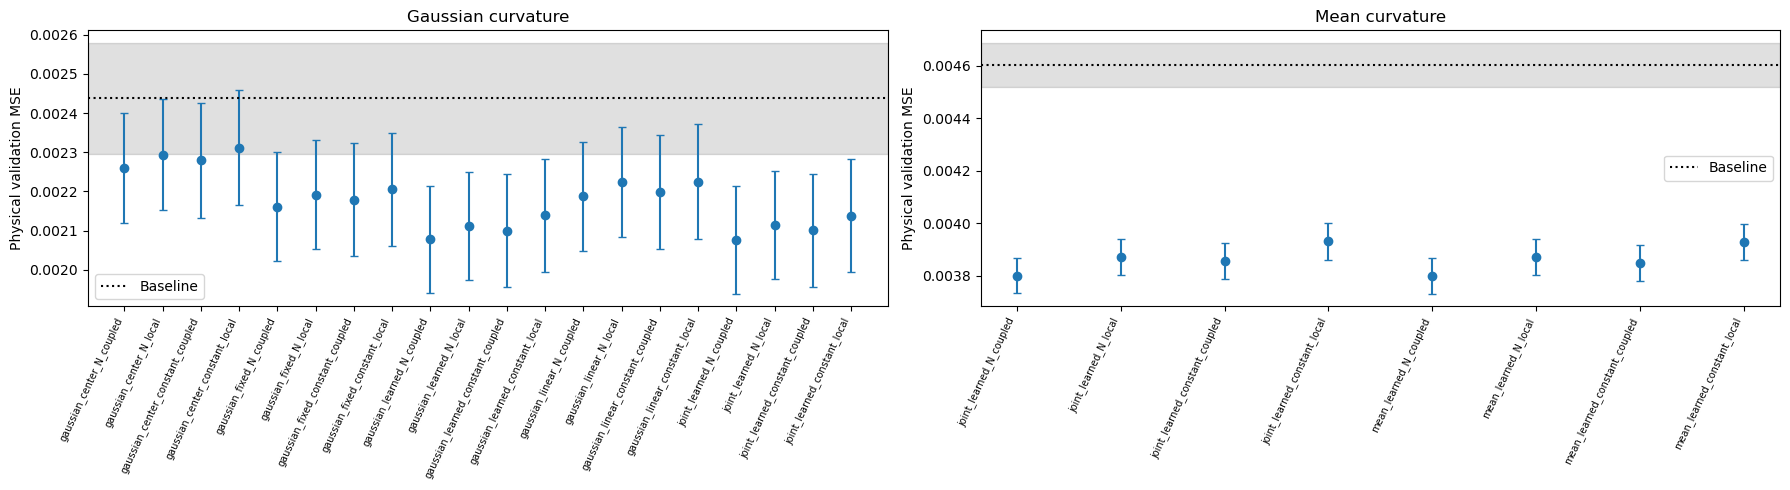

Independently restored: joint_learned_N_local_f1_s42


In [6]:
if RUN_TRAINING:
    frame=pd.read_csv(RUN_DIR/'validation_mse.csv')
    fig,axes=plt.subplots(1,2,figsize=(18,5))
    for target,ax in enumerate(axes):
        data=frame[frame.target==target]
        stats=data.groupby('name').mse.agg(['mean','sem'])
        ax.errorbar(np.arange(len(stats)),stats['mean'],yerr=stats['sem'],fmt='o',capsize=3)
        ax.set_xticks(np.arange(len(stats)),stats.index,rotation=65,ha='right',fontsize=7)
        base=data.drop_duplicates('organoid_str').baseline_mse
        ax.axhline(base.mean(),color='black',ls=':',label='Baseline')
        ax.axhspan(base.mean()-base.sem(),base.mean()+base.sem(),alpha=.12,color='black')
        ax.set(title=['Gaussian curvature','Mean curvature'][target],ylabel='Physical validation MSE');ax.legend()
    fig.tight_layout();fig.savefig(RUN_DIR/'training_mse.png',dpi=150);plt.show()
    restored=load_bundle(RUN_DIR/records[-1]['bundle'])
    print('Independently restored:',restored['record']['key'])